# **Hate Speech Detection**

### **Description**

Contains the Collection of comments, has to be classified as:

0 - neither

1 - offensive language

2 - hate speech

# **RNN Assesment**

## **1. Text Preprocessing, Tokenization, and Sequence Padding:**

In this section, you will perform data preprocessing, tokenization, and padding on the raw tweet data:

* Load the dataset: Use Pandas to load the raw tweet data.
* Clean the text: Perform the following preprocessing steps on the text:
  * Lowercase all text to ensure uniformity.
  * Remove URLs, mentions (@user), hashtags (#),
numbers, and special characters.
  * Handle contractions (e.g., "don’t" → "do not").
  * Remove stopwords and lemmatize words to reduce words to their base form.
* Visualize the cleaned data: Use tools like a word cloud or display the most frequent words to explore
the cleaned data.

* Tokenization and Padding: Convert the cleaned text data into sequences and ensure uniform se-
quence lengths by applying padding:

  * Split the dataset into 80% training and 20% testing using train test split.
  * Use Keras Tokenizer to convert the text into sequences of integers.
  * Apply padding to ensure all sequences have the same length. Utilize percentile-based padding to
avoid excessively long sequences.

### **Import Necessary Library**

In [ ]:
!pip install numpy pandas matplotlib scikit-learn tensorflow nltk

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### **Load the dataset using Pandas**

In [ ]:
data = pd.read_csv('hatevsoffensive_language.csv')

In [ ]:
data.shape


(24783, 2)

### **Data Cleaning:**

In [ ]:
from contractions import fix

In [ ]:
def preprocess_text(text):
    # Handle contractions
    text = fix(text)
    # Lowercase
    text = text.lower()
    # Remove URLs, mentions, hashtags, punctuation, and numbers
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # Tokenize and lemmatize
    stop_words = set(stopwords.words('english')) - {'not', 'no'}  # Keep negations
    lemmatizer = WordNetLemmatizer()
    tokens = text.split()
    # For short texts, reduce stopword removal
    if len(tokens) <= 3:  # If text is very short, keep all words
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    else:
        tokens = [lemmatizer.lemmatize(word) if word not in {'not', 'no'} else word
                  for word in tokens if word not in stop_words]
    cleaned_text = ' '.join(tokens)
    # Return None for empty or insufficient text
    if not cleaned_text.strip() or len(cleaned_text.split()) < 1:
        return None
    return cleaned_text

In [ ]:
data['cleaned_text'] = data['text'].apply(preprocess_text)  # Replace 'text_column' with the name of your text column

In [ ]:
data.head()

,label,text,cleaned_text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...,rt woman not complain cleaning house amp man a...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dat coldtyga dwn bad cuffin dat hoe st ...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt ever fuck bitch start cry confused ...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt look like tranny
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt shit hear might true might faker bitch told ya


In [ ]:
# Get the unique labels from the 'label' column
unique_labels = data['label'].unique()

# Print the unique labels
print("Unique Labels in the Database:", unique_labels)

Unique Labels in the Database: ['neither' 'offensive language' 'hate speec']


### **Data Visualizations:**

In [ ]:
!pip install wordcloud

**Wordcloud visualizations**

In [ ]:
from wordcloud import WordCloud

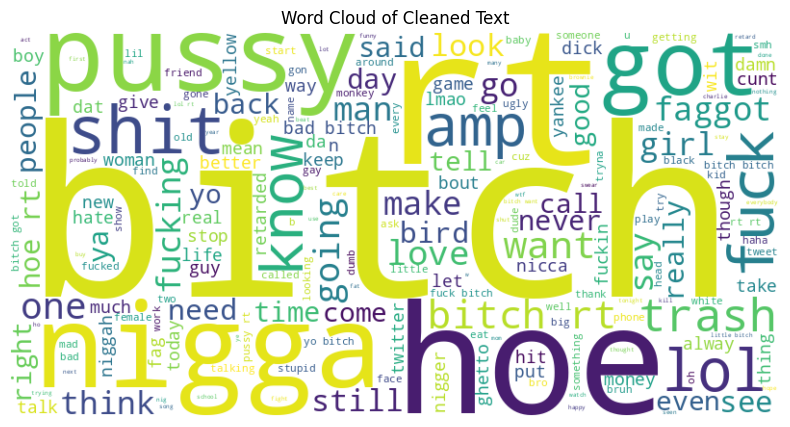

In [ ]:
all_words = ' '.join(data['cleaned_text'].astype(str)) # Convert the series to string type before joining

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Text')
plt.show()

### **Tokenization & Padding**

* Split the dataset into 80% training and 20% testing using train test split.
* Use Keras Tokenizer to convert text into sequences.
* Apply padding to ensure uniform sequence lengths (use percentile-based padding).

**1. Split the data**

In [ ]:
# Split the dataset
X = data['cleaned_text'].fillna('')  # Replace None with empty string for now
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Encode labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

**2. Tokenization Using Training Data:**

In [ ]:
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')

tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)  # Convert text to sequences
X_test_seq = tokenizer.texts_to_sequences(X_test)   # Convert test text to sequences

**3. Padding:**

**Percentile-Based Padding**

In [ ]:
seq_lengths = [len(seq) for seq in X_train_seq]
max_length = int(np.percentile(seq_lengths, 95))

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

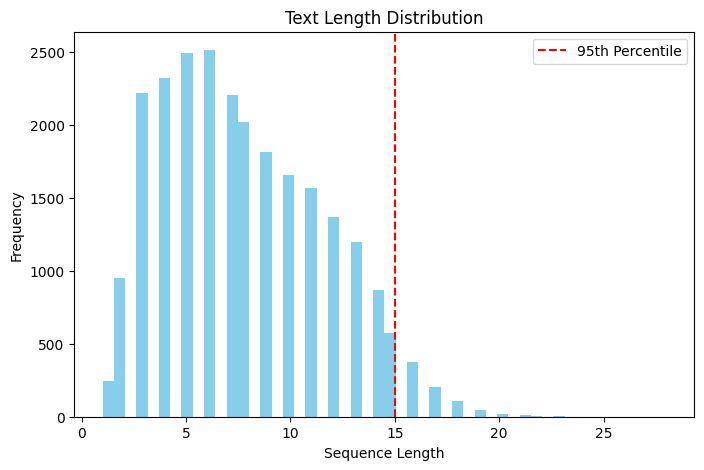

In [ ]:
X_seq = tokenizer.texts_to_sequences(data['cleaned_text'].dropna().astype(str)) # dropna() to handle None values and astype(str) to ensure strings
seq_lengths = [len(seq) for seq in X_seq]

plt.figure(figsize=(8, 5))
plt.hist(seq_lengths, bins=50, color='skyblue')
plt.title('Text Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='dashed', label='95th Percentile')
plt.legend()
plt.show()

## **2. Model Building and Training:**

In this section, you will build three different models for text classification:

1. Simple RNN with a trainable Embedding layer.
2. LSTM with a trainable Embedding layer.
3. LSTM with pretrained Word2Vec embeddings.

Each module most include:
* Embedding Layer:
  * For model1 and 2 use Embedding layer:
* rnn model.add(Embedding(input dim= , output dim= , input length= ))
  * For model 3 Use Word2Vec pretrained embeddings {A sample implementation is provided at the
Appendix Section of this document.}
* Recurrent Layer: SimpleRNN for model 1 and LSTM for models 2 and 3.
* Dense Output Layer:

**1. Simple RNN with Trainable Embedding Layer**

In [ ]:
vocab_size = 20000  # Adjust based on your tokenizer
embedding_dim = 128
max_length = 50    # Adjust based on your padding

model1 = Sequential()
model1.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
model1.add(SimpleRNN(units=64))  # Adjust units as needed
model1.add(Dense(3, activation='softmax'))  # For binary classification

model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Build the model by providing input shape (This is the key change)
model1.build(input_shape=(None, max_length))

model1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,572,547 (9.81 MB)

 Trainable params: 2,572,547 (9.81 MB)

 Non-trainable params: 0 (0.00 B)

**2. LSTM with Trainable Embedding Layer**

In [ ]:
vocab_size = 20000  # Adjust based on your tokenizer
embedding_dim = 128
max_length = 50     # Adjust based on your padding

model2 = Sequential()
model2.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
model2.add(LSTM(units=64))  # Adjust units as needed
model2.add(Dense(3, activation='softmax'))  # For binary classification

model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Build the model by providing input shape (This is the key change)
model2.build(input_shape=(None, max_length))

model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,603 (9.95 MB)

 Trainable params: 2,609,603 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
!pip install gensim --force-reinstall --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 201.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 251.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 214.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 246.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 285.5 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: smart-open
    Found existing installation: smart-open 7.1.0
    Uninstalling smart-open-7.1.0:
      Successfully 

**3. LSTM with Pretrained Word2Vec Embeddings**

In [ ]:
import numpy as np
import gensim.downloader as api
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.initializers import Constant

# Load pre-trained Word2Vec model (example: 'word2vec-google-news-300')
word2vec_model = api.load('word2vec-google-news-300')

# Set embedding_dim to match the Word2Vec model dimension
embedding_dim = word2vec_model.vector_size  # This will set it to 300 (for Google News)

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size and word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]

# Build the model
model3 = Sequential()
model3.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    embeddings_initializer=Constant(embedding_matrix),
                    input_length=max_length,
                    trainable=False))  # Set trainable to False for pre-trained embeddings
model3.add(LSTM(units=64))  # Adjust units as needed
model3.add(Dense(3, activation='softmax'))  # For multi-class classification (3 classes)

# Compile the model
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Build the model by providing input shape (This is the key change)
model3.build(input_shape=(None, max_length))

model3.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 300)        │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,093,635 (23.25 MB)

 Trainable params: 93,635 (365.76 KB)

 Non-trainable params: 6,000,000 (22.89 MB)

## **3. Model Training and Evaluation:**

Now, compile, train, and evaluate your models:

* Compile models with following configurations:
  * Appropriate Loss Function.
  * Appropriate optimizer.
  * Appropriate Metrics.
* Train the Models for desired number of epochs using callbacks and early stopping.
* Visualization:
  * Plot the Training vs. Validation loss and accuracy over epochs.
  * Compare the performance of the Model 1 vs. Model 2 vs. Model 3.
* Evaluate the models using:
 * Accuracy.
 * Confusion Matrix.
 * Classification Report.

**1. Model Compilation**

In [ ]:
model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

**2. Model Training with Callbacks and Early Stopping**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
                                        class_weight = "balanced",
                                        classes = np.unique(y_train),
                                        y = y_train
                                    )
class_weights = dict(enumerate(class_weights))

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Define ModelCheckpoint callback to save the best model
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min')

# Now proceed with model training:

# Model 1: RNN
print("-" * 20, "Training Model 1: RNN", "-" * 20)  # Separator for Model 1
history1 = model1.fit(X_train_pad, y_train, epochs=10, batch_size=32,
                    validation_split=0.2, callbacks=[early_stopping, model_checkpoint])
print("\n") # Add a newline for spacing

# Model 2: LSTM
print("-" * 20, "Training Model 2: LSTM", "-" * 20)  # Separator for Model 2
history2 = model2.fit(X_train_pad, y_train, epochs=10, batch_size=32,
                    validation_split=0.2, callbacks=[early_stopping, model_checkpoint])
print("\n") # Add a newline for spacing

# Model 3: LSTM with Word2Vec
print("-" * 20, "Training Model 3: LSTM with Word2Vec", "-" * 20)  # Separator for Model 3
history3 = model3.fit(X_train_pad, y_train, epochs=10, batch_size=32,
                    validation_split=0.2, callbacks=[early_stopping, model_checkpoint],
                       class_weight=class_weights)
print("\n") # Add a newline for spacing

-------------------- Training Model 1: RNN --------------------
Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8211 - loss: 0.5197

496/496 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8212 - loss: 0.5195 - val_accuracy: 0.8918 - val_loss: 0.3077
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9333 - loss: 0.1991 - val_accuracy: 0.8979 - val_loss: 0.3215
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9699 - loss: 0.0914 - val_accuracy: 0.8918 - val_loss: 0.3788
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9832 - loss: 0.0530 - val_accuracy: 0.8843 - val_loss: 0.4145


-------------------- Training Model 2: LSTM --------------------
Epoch 1/10
488/496 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8137 - loss: 0.5269

496/496 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8145 - loss: 0.5245 - val_accuracy: 0.9017 - val_loss: 0.2877
Epoch 2/10
490/496 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9247 - loss: 0.2214

496/496 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9247 - loss: 0.2214 - val_accuracy: 0.9037 - val_loss: 0.2706
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9509 - loss: 0.1415 - val_accuracy: 0.8875 - val_loss: 0.3209
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9674 - loss: 0.0995 - val_accuracy: 0.8855 - val_loss: 0.3599
Epoch 5/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9783 - loss: 0.0700 - val_accuracy: 0.8941 - val_loss: 0.3759


-------------------- Training Model 3: LSTM with Word2Vec --------------------
Epoch 1/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6775 - loss: 0.8194 - val_accuracy: 0.8316 - val_loss: 0.4563
Epoch 2/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7914 - loss: 0.5518 - val_accuracy: 0.7461 - val_loss: 0.6333
Epoch 3/10
496/496 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7739 - loss: 0.5010 - val_accuracy: 0.7708 - val_loss: 0.5516
Epoch 4/10
496/496 ━━━━━━━━━━━━━━━

**3. Visualization**

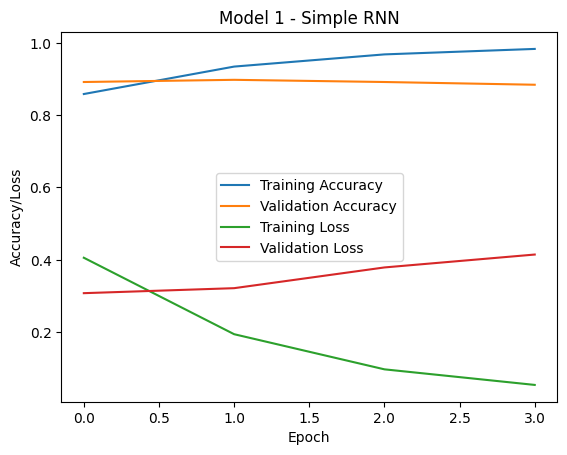

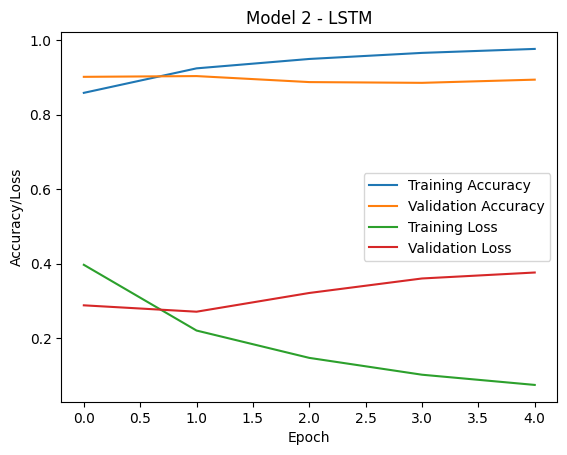

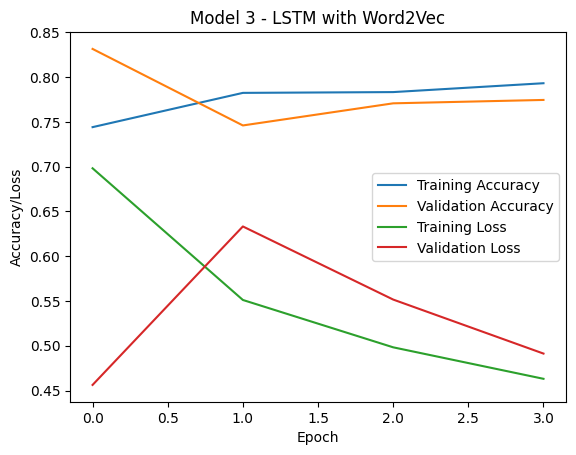

In [ ]:
import matplotlib.pyplot as plt

# Function to plot training history
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy/Loss')
    plt.legend()
    plt.show()

# Plot training histories for each model
plot_history(history1, 'Model 1 - Simple RNN')
plot_history(history2, 'Model 2 - LSTM')
plot_history(history3, 'Model 3 - LSTM with Word2Vec')

**4. Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred1 = model1.predict(X_test_pad)
y_pred2 = model2.predict(X_test_pad)
y_pred3 = model3.predict(X_test_pad)

# Get the class with the highest probability for each prediction
y_pred1 = np.argmax(y_pred1, axis=1)
y_pred2 = np.argmax(y_pred2, axis=1)
y_pred3 = np.argmax(y_pred3, axis=1)

# Calculate and print evaluation metrics for each model
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy}")
    print("Confusion Matrix:\n", conf_matrix)
    print("Classification Report:\n", class_report)

evaluate_model(y_test, y_pred1, "Model 1 - Simple RNN")
evaluate_model(y_test, y_pred2, "Model 2 - LSTM")
evaluate_model(y_test, y_pred3, "Model 3 - LSTM with Word2Vec")

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- Model 1 - Simple RNN ---
Accuracy: 0.8868267097034497
Confusion Matrix:
 [[  52   35  203]
 [   4  625  206]
 [  27   86 3719]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.18      0.28       290
           1       0.84      0.75      0.79       835
           2       0.90      0.97      0.93      3832

    accuracy                           0.89      4957
   macro avg       0.79      0.63      0.67      4957
weighted avg       0.87      0.89      0.87      4957

--- Model 2 - LSTM ---
Accuracy: 0.8924752874722615
Confusion Matrix:
 [[  67   30  193]
 [  12  724   99]
 [  58  141 3633]]
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.23      0.31       290
           1       0.81      0.87      0.84       835
           2       0.93    

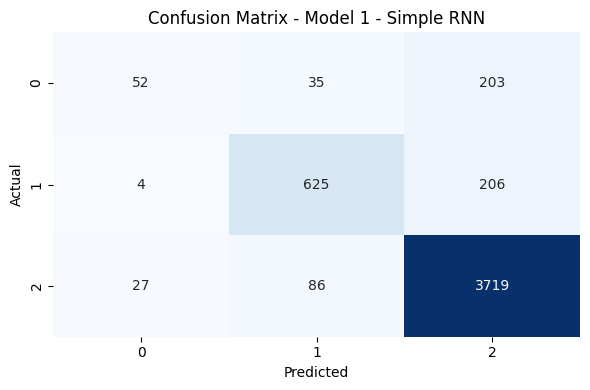

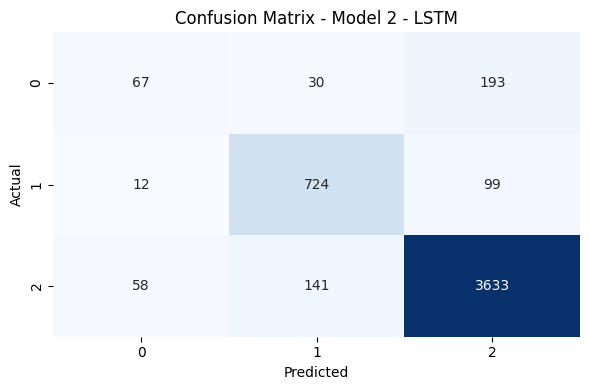

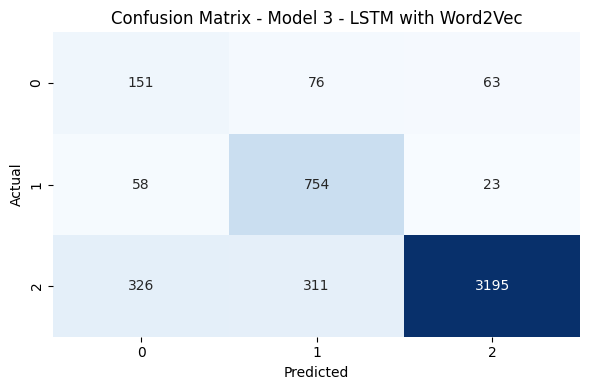

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
conf_matrix1 = confusion_matrix(y_test, y_pred1)
conf_matrix2 = confusion_matrix(y_test, y_pred2)
conf_matrix3 = confusion_matrix(y_test, y_pred3)

# Plotting function
def plot_conf_matrix(conf_matrix, model_name):
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# Plot confusion matrices for all models
plot_conf_matrix(conf_matrix1, "Model 1 - Simple RNN")
plot_conf_matrix(conf_matrix2, "Model 2 - LSTM")
plot_conf_matrix(conf_matrix3, "Model 3 - LSTM with Word2Vec")


## **4. GUI for Real-Time Prediction**

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.1/323.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 6.7 MB/s eta 0:00:00


In [ ]:
import gradio as gr

In [ ]:
def predict_tweet(tweet):
    # Preprocess
    cleaned_tweet = preprocess_text(tweet)
    if not cleaned_tweet.strip():  # Check if the cleaned text is empty
        return "Input is too short or contains only stopwords."

    # Tokenize and pad
    tweet_seq = tokenizer.texts_to_sequences([cleaned_tweet])
    tweet_pad = pad_sequences(tweet_seq, maxlen=max_length, padding='post', truncating='post')

 # Predict
    prediction = model3.predict(tweet_pad)
    predicted_class = np.argmax(prediction, axis=1)[0]

    # Map class to label
    label_map = {
        0: "neither",
        1: "offensive language",
        2: "hate speech"
    }

    return label_map[predicted_class]

In [ ]:
iface = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(lines=2, placeholder="Enter your tweet here..."),
    outputs="text",
    title="Hate Speech Detection",
    description="Enter a tweet to check if it contains hate speech."
)

iface.launch(share=True)  # Set share=True to get a public URL for sharing

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://de162533933a3ba92e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
